# **Klasifikasi dengan ektraksi fitur menggunakan  Latent Dirichlet Allocation (LDA)**

In [ ]:
!pip install gensim

In [ ]:
!pip install gensim matplotlib seaborn scikit-learn pandas numpy

In [ ]:
!pip install umap-learn

In [ ]:
import pandas as pd
import numpy as np
import gensim
from gensim import corpora, models
from gensim.models.ldamodel import LdaModel
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Membaca Data
df_path = "/content/drive/MyDrive/Crawling/berita_cnn_tokens.csv"
df = pd.read_csv(df_path)

df.head()

,id_berita,judul_berita,isi_berita,kategori_berita,cleaned,no_stopwords,stemmed,tokens
0,1,PM Qatar Desak Dunia Setop Pakai Standar Ganda...,Perdana MenteriQatarSheikh Mohammed bin Abdulr...,internasional,perdana menteriqatarsheikh mohammed bin abdulr...,perdana menteriqatarsheikh mohammed bin abdulr...,perdana menteriqatarsheikh mohammed bin abdulr...,"['perdana', 'menteriqatarsheikh', 'mohammed', ..."
1,2,"Pengadilan Tak Mau Hukum Pengedar Miras, Akhir...",Sejarah pengambilalihan aset oleh pemerintahAm...,internasional,sejarah pengambilalihan aset oleh pemerintaham...,sejarah pengambilalihan aset pemerintahamerika...,sejarah pengambilalihan aset pemerintahamerika...,"['sejarah', 'pengambilalihan', 'aset', 'pemeri..."
2,3,"Hasil Liga Inggris: Man City Bantai MU, Haalan...",Manchester Cityberhasil membantaiManchester Un...,olahraga,manchester cityberhasil membantaimanchester un...,manchester cityberhasil membantaimanchester un...,manchester cityberhasil membantaimanchester un...,"['manchester', 'cityberhasil', 'membantaimanch..."
3,4,Danau Terbesar di Inggris Raya 'Sekarat' Akiba...,"Danau terbesar diInggris Raya, Lough Neagh, di...",internasional,danau terbesar diinggris raya lough neagh dise...,danau terbesar diinggris raya lough neagh dise...,danau besar inggris raya lough neagh sebut ala...,"['danau', 'besar', 'inggris', 'raya', 'lough',..."
4,5,Rizky Ridho Ungkap Niat Main di Luar Negeri: T...,"KaptenPersija Jakarta,Rizky Ridhomembuka dialo...",olahraga,kaptenpersija jakarta rizky ridhomembuka dialo...,kaptenpersija jakarta rizky ridhomembuka dialo...,kaptenpersija jakarta rizky ridhomembuka dialo...,"['kaptenpersija', 'jakarta', 'rizky', 'ridhome..."


In [ ]:
df[['kategori_berita', 'stemmed']].head()

,kategori_berita,stemmed
0,internasional,perdana menteriqatarsheikh mohammed bin abdulr...
1,internasional,sejarah pengambilalihan aset pemerintahamerika...
2,olahraga,manchester cityberhasil membantaimanchester un...
3,internasional,danau besar inggris raya lough neagh sebut ala...
4,olahraga,kaptenpersija jakarta rizky ridhomembuka dialo...


In [ ]:
# daftar kategori unik
print(df['kategori_berita'].unique())

# Menghitung jumlah kategori unik
print("Jumlah kategori:", df['kategori_berita'].nunique())

# melihat jumlah data per kategori
print(df['kategori_berita'].value_counts())

['internasional' 'olahraga' 'nasional' 'hiburan' 'gaya-hidup' 'ekonomi'
 'tv' 'otomotif' 'edukasi' 'teknologi']
Jumlah kategori: 10
kategori_berita
nasional         227
olahraga         165
ekonomi          165
internasional    129
tv               104
gaya-hidup        57
hiburan           41
teknologi         27
edukasi           25
otomotif          21
Name: count, dtype: int64


## **Siapkan data untuk LDA**

In [ ]:
# mengubah string list token menjadi list Python
import ast
df['tokens'] = df['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Buat kamus (dictionary) dan corpus untuk Gensim
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

print("Jumlah dokumen:", len(corpus))
print("Jumlah kata unik:", len(dictionary))

Jumlah dokumen: 961
Jumlah kata unik: 14963


## **Training Model LDA**

In [ ]:

num_topics = 15

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto'
)

for i, topic in lda_model.show_topics(num_topics=num_topics, num_words=10, formatted=False):
    print(f"\nTopik {i+1}:")
    print(", ".join([word for word, prob in topic]))




Topik 1:
jadi, jantung, sebut, beri, orang, tahap, lebih, allah, diri, baik

Topik 2:
bank, diskon, indonesia, mega, transmart, jadi, rp, allo, harga, hari

Topik 3:
jadi, masyarakat, lalu, sebut, kata, pertamina, kerja, hingga, indonesia, usaha

Topik 4:
indonesia, korban, banjir, kabupaten, titik, sebut, jadi, tim, orang, laku

Topik 5:
rp, bank, triliun, perintah, indonesia, uang, sebut, ekonomi, jadi, purbaya

Topik 6:
sebut, jadi, kata, ledak, polisi, veda, presiden, indonesia, laku, balap

Topik 7:
lebih, sehat, jadi, haji, pajak, sebut, menteri, orang, milik, tingkat

Topik 8:
dunia, indonesia, piala, irak, tim, jadi, kualifikasi, timnas, lawan, arab

Topik 9:
israel, serang, negara, sebut, qatar, hamas, nyata, satu, rusia, kata

Topik 10:
sebut, tembak, kirk, kata, orang, trump, jadi, tahun, laku, as

Topik 11:
bagi, unit, jadi, kerja, musim, hujan, waktu, sebut, scroll, content

Topik 12:
jadi, kata, orang, sebut, negara, bal, ada, perintah, banjir, rumah

Topik 13:
kata, men

## **Ubah hasil LDA menjadi fitur numerik**

In [ ]:
def get_topic_distribution(lda_model, corpus):
    topic_features = []
    for doc in corpus:
        topic_dist = [0] * lda_model.num_topics
        for topic_num, prob in lda_model.get_document_topics(doc):
            topic_dist[topic_num] = prob
        topic_features.append(topic_dist)
    return np.array(topic_features)

X_lda = get_topic_distribution(lda_model, corpus)
y = df['kategori_berita']

print("Ekstraksi fitur LDA selesai.")
X_lda.shape

Ekstraksi fitur LDA selesai.


(961, 15)

In [ ]:
#Menggabungkan hasil LDA dengan kategori berita
df_lda = pd.DataFrame(X_lda, columns=[f"Topik_{i+1}" for i in range(X_lda.shape[1])])
df_lda['kategori_berita'] = df['kategori_berita'].values

df_lda.head()


,Topik_1,Topik_2,Topik_3,Topik_4,Topik_5,Topik_6,Topik_7,Topik_8,Topik_9,Topik_10,Topik_11,Topik_12,Topik_13,Topik_14,Topik_15,kategori_berita
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.01344,0.395832,0.000000,0.000000,0.589068,0.000000,0.0,0.000000,internasional
1,0.0,0.0,0.270281,0.0,0.0,0.0,0.065754,0.00000,0.000000,0.331338,0.331229,0.000000,0.000000,0.0,0.000000,internasional
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.998504,olahraga
3,0.0,0.0,0.961627,0.0,0.0,0.0,0.036981,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,internasional
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.147151,0.0,0.849688,olahraga


## **Bagi Data Train dan Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Jumlah data latih: {len(X_train)}, data uji: {len(X_test)}")


Jumlah data latih: 768, data uji: 193


## **Training Model SVM**

In [ ]:
svm_model = SVC(kernel='rbf', C=15, random_state=42)
svm_model.fit(X_train, y_train)

print("Model SVM berhasil dilatih dengan fitur hasil ekstraksi LDA.")

Model SVM berhasil dilatih dengan fitur hasil ekstraksi LDA.


## **Evaluasi Model**

In [ ]:
y_pred = svm_model.predict(X_test)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))


Akurasi Model: 0.6424870466321243

Laporan Klasifikasi:
                precision    recall  f1-score   support

      edukasi       0.00      0.00      0.00         5
      ekonomi       0.50      0.79      0.61        33
   gaya-hidup       0.62      0.42      0.50        12
      hiburan       0.00      0.00      0.00         8
internasional       0.69      0.92      0.79        26
     nasional       0.63      0.74      0.68        46
     olahraga       0.97      0.94      0.95        33
     otomotif       0.00      0.00      0.00         4
    teknologi       0.00      0.00      0.00         5
           tv       0.40      0.19      0.26        21

     accuracy                           0.64       193
    macro avg       0.38      0.40      0.38       193
 weighted avg       0.58      0.64      0.59       193



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Visualisasi Confusion Matrix**

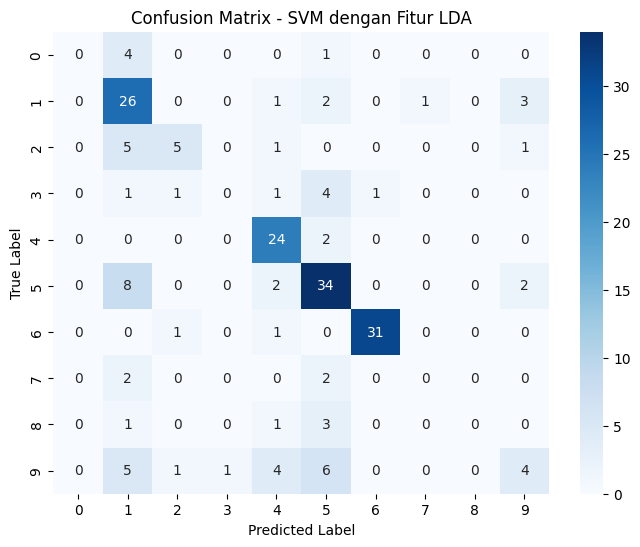

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM dengan Fitur LDA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## **Distribusi Topik per Kategori**

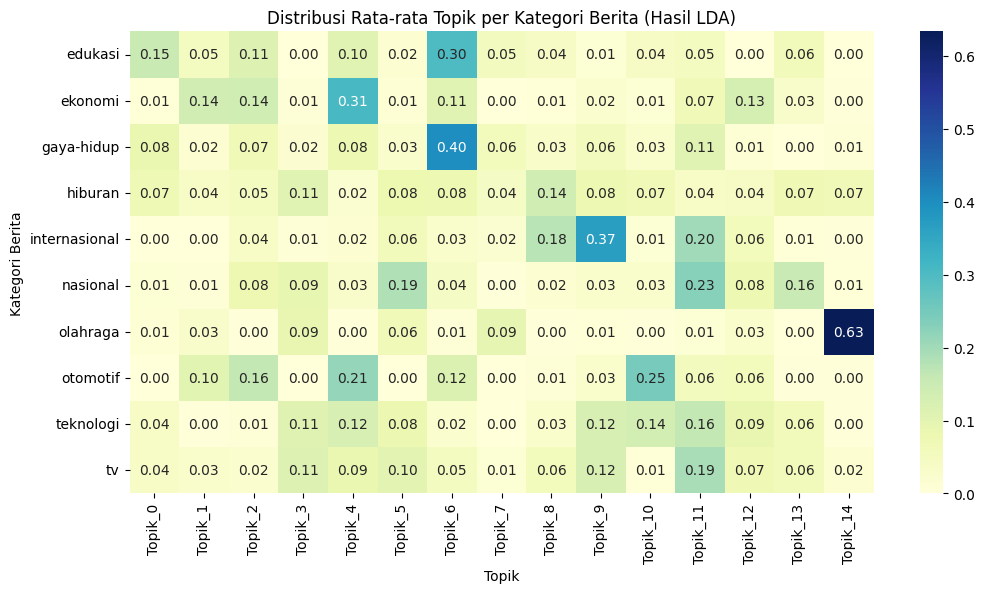

In [ ]:
topic_df = pd.DataFrame(X_lda, columns=[f"Topik_{i}" for i in range(num_topics)])
topic_df["Kategori"] = y.values

topic_by_category = topic_df.groupby("Kategori").mean()

plt.figure(figsize=(12,6))
sns.heatmap(topic_by_category, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Distribusi Rata-rata Topik per Kategori Berita (Hasil LDA)")
plt.xlabel("Topik")
plt.ylabel("Kategori Berita")
plt.show()


## **Topik Dominan per Dokumen**

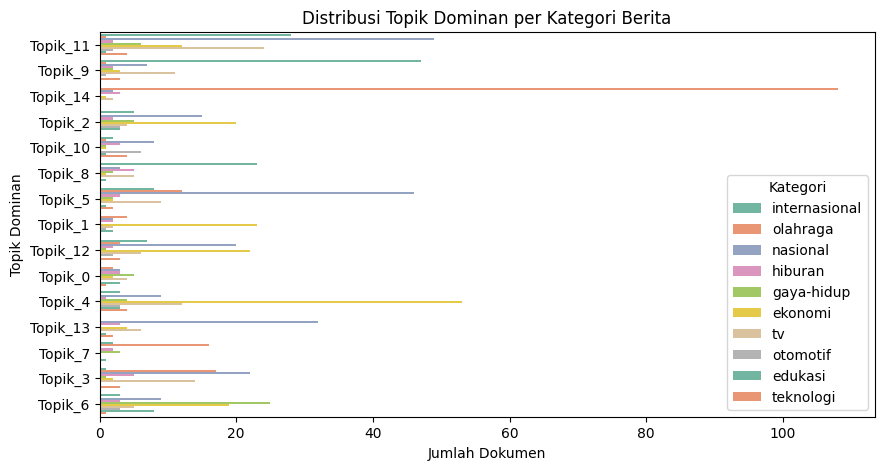

In [ ]:
topic_df["Topik_Dominan"] = topic_df[[f"Topik_{i}" for i in range(num_topics)]].idxmax(axis=1)

plt.figure(figsize=(10,5))
sns.countplot(y="Topik_Dominan", hue="Kategori", data=topic_df, palette="Set2")
plt.title("Distribusi Topik Dominan per Kategori Berita")
plt.xlabel("Jumlah Dokumen")
plt.ylabel("Topik Dominan")
plt.legend(title="Kategori")
plt.show()


## **Proyeksi 2D Data LDA**

In [ ]:
import umap
# Buat model UMAP
umap_model = umap.UMAP(n_neighbors=15, n_components=2, random_state=42)

# Fit-transform untuk data training dan test
X_train_2d = umap_model.fit_transform(X_train)
X_test_2d = umap_model.transform(X_test)

# Simpan hasil proyeksi ke DataFrame
train_umap = pd.DataFrame(X_train_2d, columns=['x', 'y'])
train_umap['Kategori'] = y_train.values

test_umap = pd.DataFrame(X_test_2d, columns=['x', 'y'])
test_umap['Kategori'] = y_test.values


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## **Visualisasi**

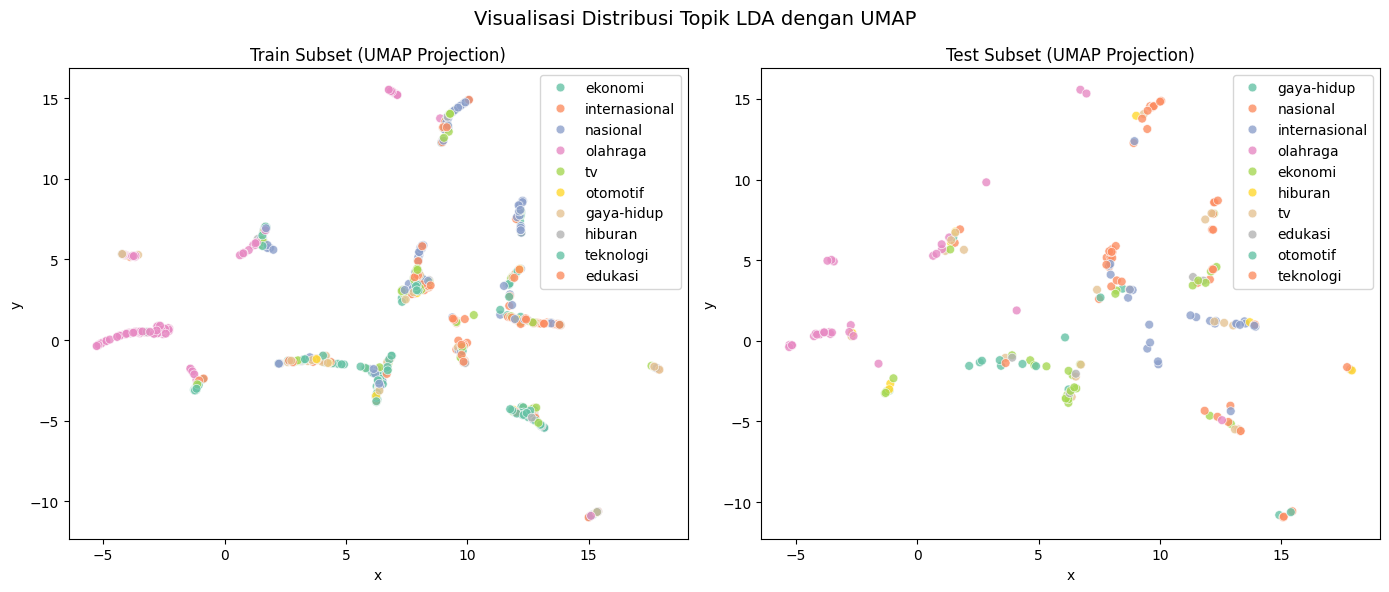

In [ ]:
plt.figure(figsize=(14,6))

# Plot subset training
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=train_umap,
    x='x', y='y',
    hue='Kategori',
    palette='Set2',
    s=40,
    alpha=0.8
)
plt.title('Train Subset (UMAP Projection)')
plt.legend(loc='best')

# Plot subset testing
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=test_umap,
    x='x', y='y',
    hue='Kategori',
    palette='Set2',
    s=40,
    alpha=0.8
)
plt.title('Test Subset (UMAP Projection)')
plt.legend(loc='best')

plt.suptitle('Visualisasi Distribusi Topik LDA dengan UMAP', fontsize=14)
plt.tight_layout()
plt.show()
